# RIESGO DE MERCADO

In [ ]:
!pip install yfinance
!pip install openpyxl

import yfinance as yf
import time
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import laplace



## **Parte I. Selección de activos**

Seleccionamos 20 acciones que pertenecen al S&P 500, las cuales son: Apple, Microsoft Corporation, The Coca-Cola Company, Adobe, Best Buy, Caterpillar, Dell Technologies, Expedia Group, Honeywell International, Iron Mountain Incorporated, JPMorgan Chase & Co, lululemon athletica, Meta, NIKE, Phillips 66, Rockwell Automation, Starbucks Corporation, Texas Instruments Incorporated, Ulta Beauty y Walmart.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

cartera = pd.read_excel('/content/cartera.xlsx')
cartera.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,AAPL,MSFT,KO,ADBE,BBY,CAT,DELL,EXPE,HON,IRM,JPM,LULU,META,NKE,PSX,ROK,SBUX,TXN,ULTA,WMT
0,182.009995,334.750000,59.299999,564.369995,102.120003,207.000000,56.980000,184.970001,206.800003,51.320000,161.699997,387.559998,338.540009,164.669998,75.739998,339.660004,116.680000,190.600006,413.230011,48.216667
1,179.699997,329.010010,60.290001,554.000000,105.139999,218.080002,58.490002,185.369995,209.000000,50.750000,167.830002,380.820007,336.529999,166.389999,78.570000,343.100006,114.239998,190.800003,418.739990,47.333332
2,174.919998,316.380005,60.790001,514.429993,103.000000,219.750000,57.980000,181.300003,211.059998,48.500000,163.779999,362.480011,324.170013,162.250000,78.320000,337.359985,110.440002,186.820007,401.489990,47.973331
3,172.000000,313.880005,60.470001,514.119995,102.879997,221.990005,58.040001,177.580002,210.820007,46.770000,165.520004,368.769989,332.459991,161.039993,80.480003,335.109985,111.139999,186.759995,400.489990,47.840000
4,172.169998,314.040009,60.330002,510.700012,102.500000,224.190002,57.990002,179.910004,215.750000,46.790001,167.160004,355.209991,331.790009,156.970001,81.959999,327.880005,107.570000,179.440002,397.100006,48.296665


### VaR no paramétrico Simulación Histórica

***- Individual***

In [ ]:
# Asegurar que el índice sea de tipo fecha (opcional)
cartera.index = pd.to_datetime(cartera.index)

# --- VARIABLES INICIALES ---
VaR_resulSH = pd.DataFrame()
d1_resultadosSH = {}

# --- CONFIGURACIÓN DE PLOTS ---
#fig, axs = plt.subplots(len(cartera.columns), 2, figsize=(10, 20))
#axs = axs.flatten()

# --- PROCESO PARA CADA EMISORA ---
for idx, emisora in enumerate(cartera.columns):
    precios = cartera[emisora].dropna()  # precios de cierre sin nulos
    d1_SH = pd.DataFrame({'Precio': precios})

    # Calcular rendimientos, revalorizaciones y pérdidas/ganancias
    d1_SH['Rend'] = d1_SH['Precio'].pct_change()
    d1_SH['Reval'] = d1_SH['Precio'].iloc[-1] * (1 + d1_SH['Rend'])
    d1_SH['PL'] = d1_SH['Precio'].iloc[-1] - d1_SH['Reval']

    d1_resultadosSH[emisora] = d1_SH.copy()

    # Media y volatilidad
    mrend_SH = d1_SH['Rend'].mean(skipna=True)
    srend_SH = d1_SH['Rend'].std(skipna=True)

    # VaR
    VaRSH = d1_SH['PL'].quantile([0.95, 0.97, 0.99])

    # Expected Shortfall (ES)
    ES_SH95 = d1_SH.loc[d1_SH['PL'] > VaRSH.loc[0.95], 'PL'].mean()
    ES_SH97 = d1_SH.loc[d1_SH['PL'] > VaRSH.loc[0.97], 'PL'].mean()
    ES_SH99 = d1_SH.loc[d1_SH['PL'] > VaRSH.loc[0.99], 'PL'].mean()

    # Horizontes de tiempo
    dias = [1, 7, 15, 30, 60, 90, 180]

    for d in dias:
        VaRSHd = VaRSH * np.sqrt(d)

        temp_SH = pd.DataFrame({
            'Emisora': [emisora],
            'Horizonte': [d],
            'Rend_SH': [mrend_SH],
            'Vol_SH': [srend_SH],
            'VaRSH_95': [VaRSHd.loc[0.95]],
            'VaRSH_97': [VaRSHd.loc[0.97]],
            'VaRSH_99': [VaRSHd.loc[0.99]],
            'ES_SH95': [ES_SH95],
            'ES_SH97': [ES_SH97],
            'ES_SH99': [ES_SH99]
        })

        VaR_resulSH = pd.concat([VaR_resulSH, temp_SH], ignore_index=True)

    # --- HISTOGRAMA ---
    #axs[idx].hist(d1_SH['PL'].dropna(), bins=20, color='lightblue')
    #axs[idx].set_title(f"Histograma de Pérdidas - {emisora}")
    #axs[idx].set_xlabel('Pérdidas o Ganancias')
    #axs[idx].set_ylabel('Frecuencia')

    # Líneas verticales para VaR
    #axs[idx].axvline(VaRSH.loc[0.95], color='gold', linewidth=2, label='VaR 95%')
    #axs[idx].axvline(VaRSH.loc[0.97], color='orange', linewidth=2, label='VaR 97%')
    #axs[idx].axvline(VaRSH.loc[0.99], color='red', linewidth=2, label='VaR 99%')
    #axs[idx].legend()

# --- MOSTRAR RESULTADOS ---
#plt.tight_layout()
#plt.show()

# --- MOSTRAR TABLA DE RESULTADOS ---
VaR_resulSH


,Emisora,Horizonte,Rend_SH,Vol_SH,VaRSH_95,VaRSH_97,VaRSH_99,ES_SH95,ES_SH97,ES_SH99
0,AAPL,1,0.000369,0.017152,6.129762,7.671698,10.112604,8.325128,9.349440,11.216915
1,AAPL,7,0.000369,0.017152,16.217826,20.297405,26.755435,8.325128,9.349440,11.216915
2,AAPL,15,0.000369,0.017152,23.740466,29.712358,39.165946,8.325128,9.349440,11.216915
3,AAPL,30,0.000369,0.017152,33.574089,42.019620,55.389012,8.325128,9.349440,11.216915
4,AAPL,60,0.000369,0.017152,47.480932,59.424717,78.331892,8.325128,9.349440,11.216915
...,...,...,...,...,...,...,...,...,...,...
135,WMT,15,0.000792,0.013410,6.234525,7.327052,10.278903,2.644985,3.232993,5.173928
136,WMT,30,0.000792,0.013410,8.816951,10.362016,14.536564,2.644985,3.232993,5.173928
137,WMT,60,0.000792,0.013410,12.469051,14.654104,20.557805,2.644985,3.232993,5.173928
138,WMT,90,0.000792,0.013410,15.271406,17.947538,25.178067,2.644985,3.232993,5.173928


Visualización de los resultados del **VaR de cada emisora**

In [ ]:
# --- Definir lista de emisoras individuales ---
individuales = ["AAPL", "NKE"]  # ejemplo

# --- Mostrar resultados de cada emisora ---
for emi in individuales:
    tabla = VaR_resulSH[
        VaR_resulSH['Emisora'] == emi
    ][['Horizonte', 'VaRSH_95', 'VaRSH_97', 'VaRSH_99']].copy()

    # Redondear a 4 decimales
    tabla = tabla.round(4)

    # Mostrar como tabla bonita
    print(f"Resultados de VaR para {emi}:\n")
    display(tabla.style.set_caption(f"Resultados de VaR para {emi}"))


Resultados de VaR para AAPL:



,Horizonte,VaRSH_95,VaRSH_97,VaRSH_99
0,1,6.129800,7.671700,10.112600
1,7,16.217800,20.297400,26.755400
2,15,23.740500,29.712400,39.165900
3,30,33.574100,42.019600,55.389000
4,60,47.480900,59.424700,78.331900
5,90,58.152000,72.780100,95.936600
6,180,82.239400,102.926600,135.674800


Resultados de VaR para NKE:



,Horizonte,VaRSH_95,VaRSH_97,VaRSH_99
91,1,2.001900,2.356700,3.660100
92,7,5.296600,6.235200,9.683700
93,15,7.753500,9.127400,14.175500
94,30,10.965100,12.908100,20.047200
95,60,15.507000,18.254800,28.351000
96,90,18.992100,22.357500,34.722700
97,180,26.858800,31.618300,49.105300


Visuaización del **Expected Shortfall** para cada emisora

In [ ]:
# --- Crear lista para guardar los resultados ---
lista_resultados = []

emisoras = VaR_resulSH['Emisora'].unique()
horizontes = VaR_resulSH['Horizonte'].unique()

for h in horizontes:
    ES_SH95 = []
    ES_SH97 = []
    ES_SH99 = []

    for emisora_actual in emisoras:
        # Filtrar por emisora y horizonte
        filtro = VaR_resulSH[
            (VaR_resulSH['Emisora'] == emisora_actual) &
            (VaR_resulSH['Horizonte'] == h)
        ]

        if not filtro.empty:
            ES_SH95.append(filtro.iloc[0]['ES_SH95'])
            ES_SH97.append(filtro.iloc[0]['ES_SH97'])
            ES_SH99.append(filtro.iloc[0]['ES_SH99'])
        else:
            ES_SH95.append(None)
            ES_SH97.append(None)
            ES_SH99.append(None)

    ES_emisoras_h = pd.DataFrame({
        'Emisora': emisoras,
        'ES_95': ES_SH95,
        'ES_97': ES_SH97,
        'ES_99': ES_SH99,
        'Horizonte': h
    })

    lista_resultados.append(ES_emisoras_h)

# --- Unir todos los resultados en un solo DataFrame ---
ES_emisoras_total = pd.concat(lista_resultados, ignore_index=True)

# --- Mostrar el resultado ---
ES_emisoras_total


,Emisora,ES_95,ES_97,ES_99,Horizonte
0,AAPL,8.325128,9.349440,11.216915,1
1,MSFT,14.823675,16.744786,20.410305,1
2,KO,1.601912,1.884115,2.623374,1
3,ADBE,23.179731,28.761692,42.215039,1
4,BBY,3.542837,4.117318,5.492869,1
...,...,...,...,...,...
135,ROK,12.208229,14.449619,21.571259,180
136,SBUX,4.108816,4.903755,6.731377,180
137,TXN,6.787226,7.641493,9.705733,180
138,ULTA,17.046295,19.824505,28.470680,180


***- Portafolio***

         AAPL        MSFT         KO        ADBE         BBY         CAT  \
0  182.009995  334.750000  59.299999  564.369995  102.120003  207.000000   
1  179.699997  329.010010  60.290001  554.000000  105.139999  218.080002   
2  174.919998  316.380005  60.790001  514.429993  103.000000  219.750000   
3  172.000000  313.880005  60.470001  514.119995  102.879997  221.990005   
4  172.169998  314.040009  60.330002  510.700012  102.500000  224.190002   

        DELL        EXPE         HON        IRM         JPM        LULU  \
0  56.980000  184.970001  206.800003  51.320000  161.699997  387.559998   
1  58.490002  185.369995  209.000000  50.750000  167.830002  380.820007   
2  57.980000  181.300003  211.059998  48.500000  163.779999  362.480011   
3  58.040001  177.580002  210.820007  46.770000  165.520004  368.769989   
4  57.990002  179.910004  215.750000  46.790001  167.160004  355.209991   

         META         NKE        PSX         ROK        SBUX         TXN  \
0  338.540009  1

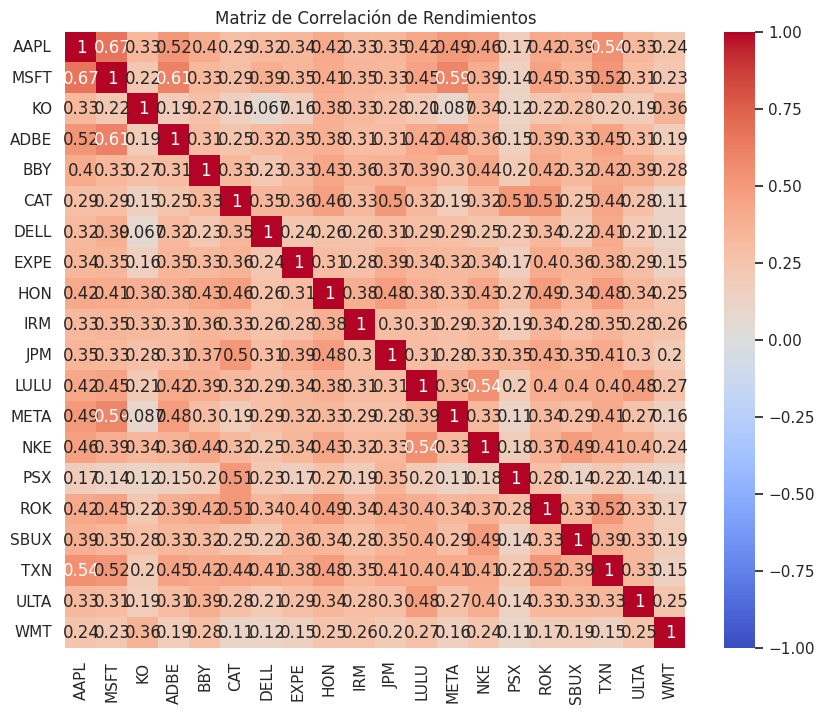

1     -7.966660
2    130.990005
3     -4.966629
4     30.413254
5     13.543335
dtype: float64


In [ ]:

# --- Cargar los precios de cierre desde el archivo Excel ---
cartera = pd.read_excel('/content/cartera.xlsx')
d2_SH = pd.DataFrame()

# Leer la hoja Sheet1, que tiene los precios de cierre en columnas
d2_SH = pd.read_excel('/content/cartera.xlsx', sheet_name='Sheet1')

# Verificar los primeros registros
print(d2_SH.head())

# --- Número de días (n) y número de emisoras (m) ---
n = d2_SH.shape[0]  # número de filas (días)
m = d2_SH.shape[1]  # número de columnas (emisoras)

# --- Cálculo de los rendimientos diarios ---
Rend = d2_SH.pct_change().iloc[1:]  # Use pct_change for percentage change

# --- Análisis de correlación ---
c = Rend.corr()

# Graficar matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(c, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Rendimientos')
plt.show()

# --- Cálculo de las Pérdidas y Ganancias (PL) ---
precio_final = d2_SH.iloc[-1]  # último precio de cada emisora

# Calcular los cambios diarios en los precios
daily_change = d2_SH.diff().iloc[1:]

# Calcular las pérdidas y ganancias diarias, las pérdidas son positivas cuando el precio baja
PL = daily_change * -1  # Las pérdidas se calculan como los cambios negativos

# --- Cálculo de la Pérdida Total del Portafolio ---
PL_total = PL.sum(axis=1)

# --- Verificar ---
print(PL_total.head())


**VaR del portafolio** y **Expected Shortfall** por Simulación Histórica:

### Tabla de VaR del Portafolio ###
           1_días    7_días   15_días   30_días   60_días   90_días   180_días
VaR_95%  -78.9917 -199.2947 -283.6993 -418.3099 -516.4215 -695.2700  -958.9970
VaR_97%  -93.5077 -223.9429 -314.3396 -470.6195 -606.9943 -763.5058 -1003.9016
VaR_99% -116.1807 -262.2991 -373.5116 -529.4587 -687.7015 -885.8864 -1061.8208

### Tabla de Expected Shortfall del Portafolio ###
        1_días  7_días  15_días  30_días  60_días   90_días  180_días
ES_95%  5.3319  9.8520  10.2934  -0.8651 -46.3101  -94.0747 -297.0065
ES_97%  3.4934  5.3853   3.8570 -10.1736 -56.8543 -107.7892 -311.5652
ES_99%  1.3681  0.4852  -3.3525 -20.2704 -68.7459 -121.5345 -325.5281


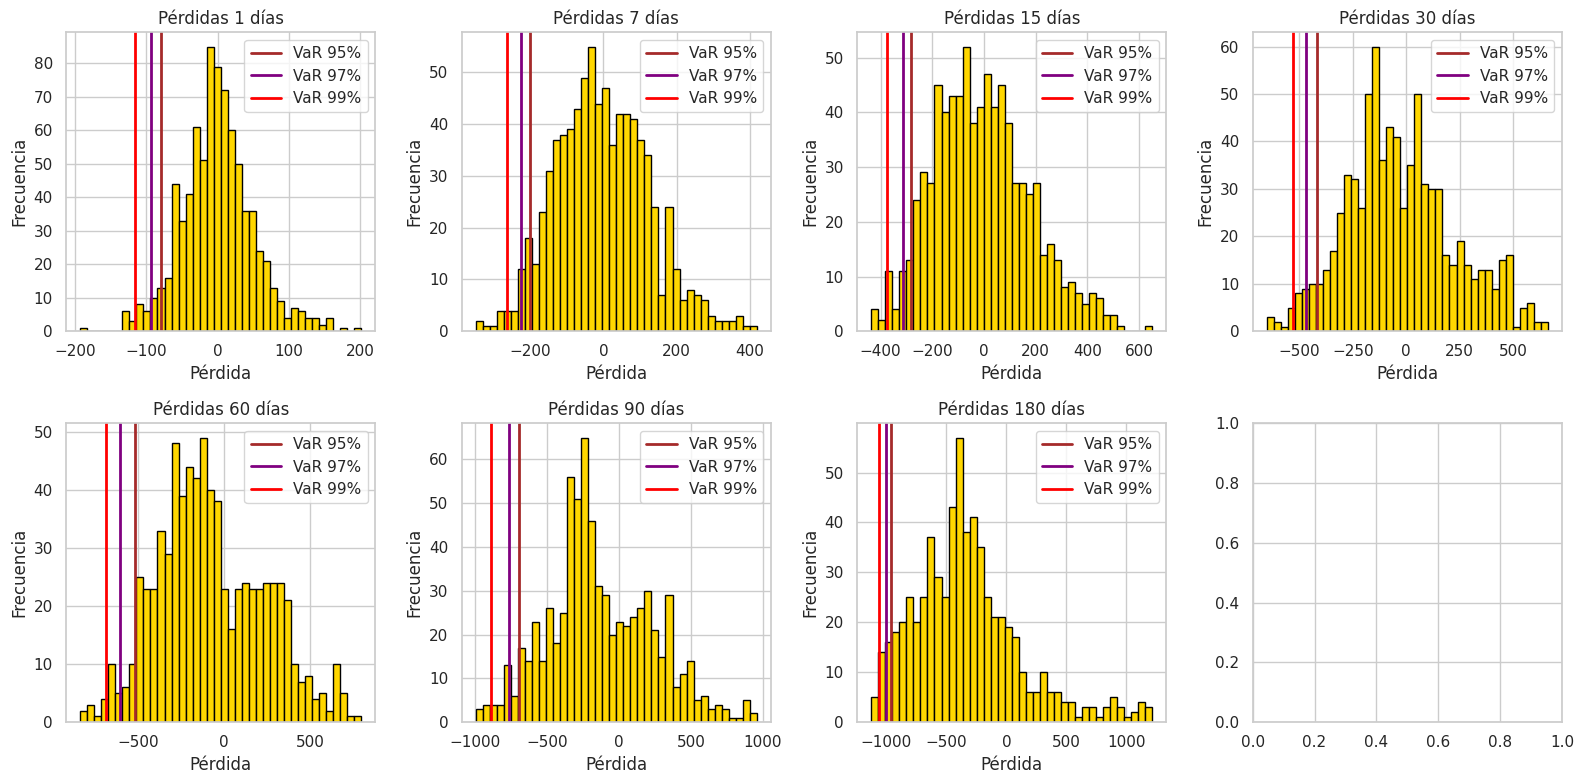

In [ ]:

# --- Definir los horizontes ---
horizontes = [1, 7, 15, 30, 60, 90, 180]

# --- Crear pérdidas acumuladas para cada horizonte ---
PL_total_list = []

for h in horizontes:
    PL_h = [sum(PL_total[i:i + h]) for i in range(len(PL_total) - h + 1)]
    PL_total_list.append(PL_h)

# --- Ajustar el tamaño de la matriz para las pérdidas acumuladas ---
longitud_maxima = max(len(lst) for lst in PL_total_list)
PL_total_mat = np.full((longitud_maxima, len(horizontes)), np.nan)

for h_idx, h in enumerate(horizontes):
    PL_total_mat[:len(PL_total_list[h_idx]), h_idx] = PL_total_list[h_idx]

# --- Nombres de los niveles de confianza ---
niveles_confianza = [0.95, 0.97, 0.99]
nombres_VaR = [f"VaR_{int(n * 100)}%" for n in niveles_confianza]
nombres_ES = [f"ES_{int(n * 100)}%" for n in niveles_confianza]

# --- Cálculo de VaR y ES ---
VaR_portSH = np.full((len(niveles_confianza), len(horizontes)), np.nan)
ES_portSH = np.full((len(niveles_confianza), len(horizontes)), np.nan)

for h_idx, h in enumerate(horizontes):
    perdidas_h = PL_total_mat[:, h_idx][~np.isnan(PL_total_mat[:, h_idx])]

    # VaR
    VaR_h = np.percentile(perdidas_h, [100 * (1 - n) for n in niveles_confianza])
    VaR_portSH[:, h_idx] = VaR_h

    # ES
    for i, nivel in enumerate(niveles_confianza):
        ES_h = np.mean(perdidas_h[perdidas_h >= VaR_h[i]])  # Expected Shortfall
        ES_portSH[i, h_idx] = ES_h

# --- Crear tablas de VaR y ES ---
VaR_df = pd.DataFrame(VaR_portSH, columns=[f"{h}_días" for h in horizontes], index=nombres_VaR)
ES_df = pd.DataFrame(ES_portSH, columns=[f"{h}_días" for h in horizontes], index=nombres_ES)

# Imprimir las tablas de VaR y Expected Shortfall
print("### Tabla de VaR del Portafolio ###")
print(VaR_df.round(4))

print("\n### Tabla de Expected Shortfall del Portafolio ###")
print(ES_df.round(4))

# --- Graficar los resultados ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for h_idx, h in enumerate(horizontes):
    perdidas_h = PL_total_mat[:, h_idx][~np.isnan(PL_total_mat[:, h_idx])]

    axes[h_idx].hist(perdidas_h, bins=40, color="gold", edgecolor="black")
    axes[h_idx].axvline(VaR_portSH[0, h_idx], color="brown", linewidth=2, label="VaR 95%")
    axes[h_idx].axvline(VaR_portSH[1, h_idx], color="purple", linewidth=2, label="VaR 97%")
    axes[h_idx].axvline(VaR_portSH[2, h_idx], color="red", linewidth=2, label="VaR 99%")
    axes[h_idx].set_title(f"Pérdidas {h} días")
    axes[h_idx].set_xlabel("Pérdida")
    axes[h_idx].set_ylabel("Frecuencia")
    axes[h_idx].legend()

plt.tight_layout()
plt.show()


### VaR no paramétrico Simulación Monte Carlo - Normalidad
***- Individual***

In [ ]:

# --- Cargar los precios de cierre desde el archivo Excel ---
cartera = pd.read_excel('/content/cartera.xlsx').columns.tolist()

# Leer los precios de cierre
d1_SMN = pd.read_excel('/content/cartera.xlsx', sheet_name='Sheet1')

# Asignar los nombres de las emisoras
d1_SMN.columns = cartera

# Convertir los precios de cierre a valores numéricos
d1_SMN = d1_SMN.apply(pd.to_numeric, errors='coerce')

# --- Cálculo de rendimientos ---
n = len(d1_SMN)

# Crear un DataFrame para almacenar los rendimientos
d1_RendSMN = pd.DataFrame(np.nan, index=d1_SMN.index, columns=cartera)

# Calcular los rendimientos diarios
for emisora in cartera:
    d1_RendSMN[emisora] = d1_SMN[emisora].pct_change()

# --- Estimación de parámetros de la distribución normal (media y desviación estándar) ---
mu = {}
sigma = {}

for emisora in cartera:
    # Eliminar valores nulos (si existen)
    y = d1_RendSMN[emisora].dropna()

    # Estimación de la media (mu) y la desviación estándar (sigma)
    mu[emisora] = y.mean()
    sigma[emisora] = y.std()

# Mostrar los resultados
print("Media (mu) de los rendimientos por emisora:")
print(mu)

print("\nDesviación estándar (sigma) de los rendimientos por emisora:")
print(sigma)


Media (mu) de los rendimientos por emisora:
{'AAPL': np.float64(0.0003686297924949918), 'MSFT': np.float64(0.0003019590629724296), 'KO': np.float64(0.00026201331365864145), 'ADBE': np.float64(-0.00017424298267682258), 'BBY': np.float64(-0.00016635498303158716), 'CAT': np.float64(0.0007449568923629008), 'DELL': np.float64(0.001024973433930897), 'EXPE': np.float64(0.00028393638944140527), 'HON': np.float64(0.00010567155723567035), 'IRM': np.float64(0.0007964710934621275), 'JPM': np.float64(0.0006254292089920097), 'LULU': np.float64(-5.4961240804783465e-06), 'META': np.float64(0.0011173910652863758), 'NKE': np.float64(-0.00094073645862487), 'PSX': np.float64(0.0007838630535269537), 'ROK': np.float64(-0.00011977631446394987), 'SBUX': np.float64(-1.4099340092174163e-05), 'TXN': np.float64(6.474838486071591e-05), 'ULTA': np.float64(5.918540597478102e-05), 'WMT': np.float64(0.0007922401132124087)}

Desviación estándar (sigma) de los rendimientos por emisora:
{'AAPL': 0.017151828910515404, 'MS

Cálculo del **VaR SM asumiendo normalidad** y del *Expected Shortfall** para cada emisora

In [ ]:

# Simulaciones
np.random.seed(123)
m = 5000  # Número de simulaciones
nc = [0.95, 0.97, 0.99]  # Niveles de confianza
t = [1, 7, 15, 30, 60, 90, 180]  # Horizontes de tiempo en días

# Lista para almacenar los resultados
lista_resultados = []

for emisora in cartera:

    # Obtener la media y desviación estándar para la emisora
    mu_emisora = mu[emisora]
    sigma_emisora = sigma[emisora]
    PrecioActual = d1_SMN[emisora].iloc[-1]  # Precio actual de la emisora

    for h in t:
        mu_h = mu_emisora * h
        sigma_h = sigma_emisora * np.sqrt(h)

        # Simulación de rendimientos
        rend_simulados = np.random.normal(loc=mu_h, scale=sigma_h, size=m)

        # Simulación de precios
        precios_simulados = PrecioActual * (1 + rend_simulados)
        PL_simulados = precios_simulados - PrecioActual

        # Cálculo de VaR para cada nivel de confianza
        VaRs = np.quantile(PL_simulados, nc)

        # Cálculo de ES para cada nivel de confianza
        ESs = [np.mean(PL_simulados[PL_simulados >= VaR]) for VaR in VaRs]

        # Almacenar resultados
        lista_resultados.append({
            'Emisora': emisora,
            'Horizonte': h,
            'Rend_SH': mu_emisora,
            'Vol_SH': sigma_emisora,
            'VaRSH_95': VaRs[0],
            'VaRSH_97': VaRs[1],
            'VaRSH_99': VaRs[2],
            'ES_SH95': ESs[0],
            'ES_SH97': ESs[1],
            'ES_SH99': ESs[2]
        })

# Convertir los resultados a un DataFrame
resultados_VaRSMN = pd.DataFrame(lista_resultados)

# Mostrar los primeros resultados
print(resultados_VaRSMN.head())


  Emisora  Horizonte   Rend_SH    Vol_SH   VaRSH_95   VaRSH_97   VaRSH_99  \
0    AAPL          1  0.000369  0.017152   6.217850   7.167964   8.703176   
1    AAPL          7  0.000369  0.017152  17.015460  19.285259  23.633440   
2    AAPL         15  0.000369  0.017152  25.578189  29.019139  35.474893   
3    AAPL         30  0.000369  0.017152  35.822553  40.016792  50.733064   
4    AAPL         60  0.000369  0.017152  49.798870  57.983105  69.554244   

     ES_SH95    ES_SH97    ES_SH99  
0   7.715611   8.429045   9.672569  
1  21.214921  23.379096  27.450867  
2  31.619051  34.607294  40.402693  
3  44.508890  48.995810  57.725335  
4  62.687598  68.582857  79.546850  


***- Portafolio***


--- VaR Simulación Monte Carlo (Normal) ---
           1 días    7 días   15 días   30 días   60 días   90 días
VaR 95% -0.007414 -0.019153 -0.025666 -0.032968 -0.039974 -0.046882
VaR 97% -0.008552 -0.021803 -0.029629 -0.039466 -0.050191 -0.056254
VaR 99% -0.010668 -0.027630 -0.036411 -0.051789 -0.065345 -0.076775

--- Expected Shortfall (ES) ---
          1 días    7 días   15 días   30 días   60 días   90 días
ES 95%  0.000834  0.003000  0.006221  0.012050  0.023029  0.031141
ES 97%  0.000653  0.002519  0.005525  0.011057  0.021632  0.029446
ES 99%  0.000448  0.001982  0.004749  0.009931  0.020052  0.027541


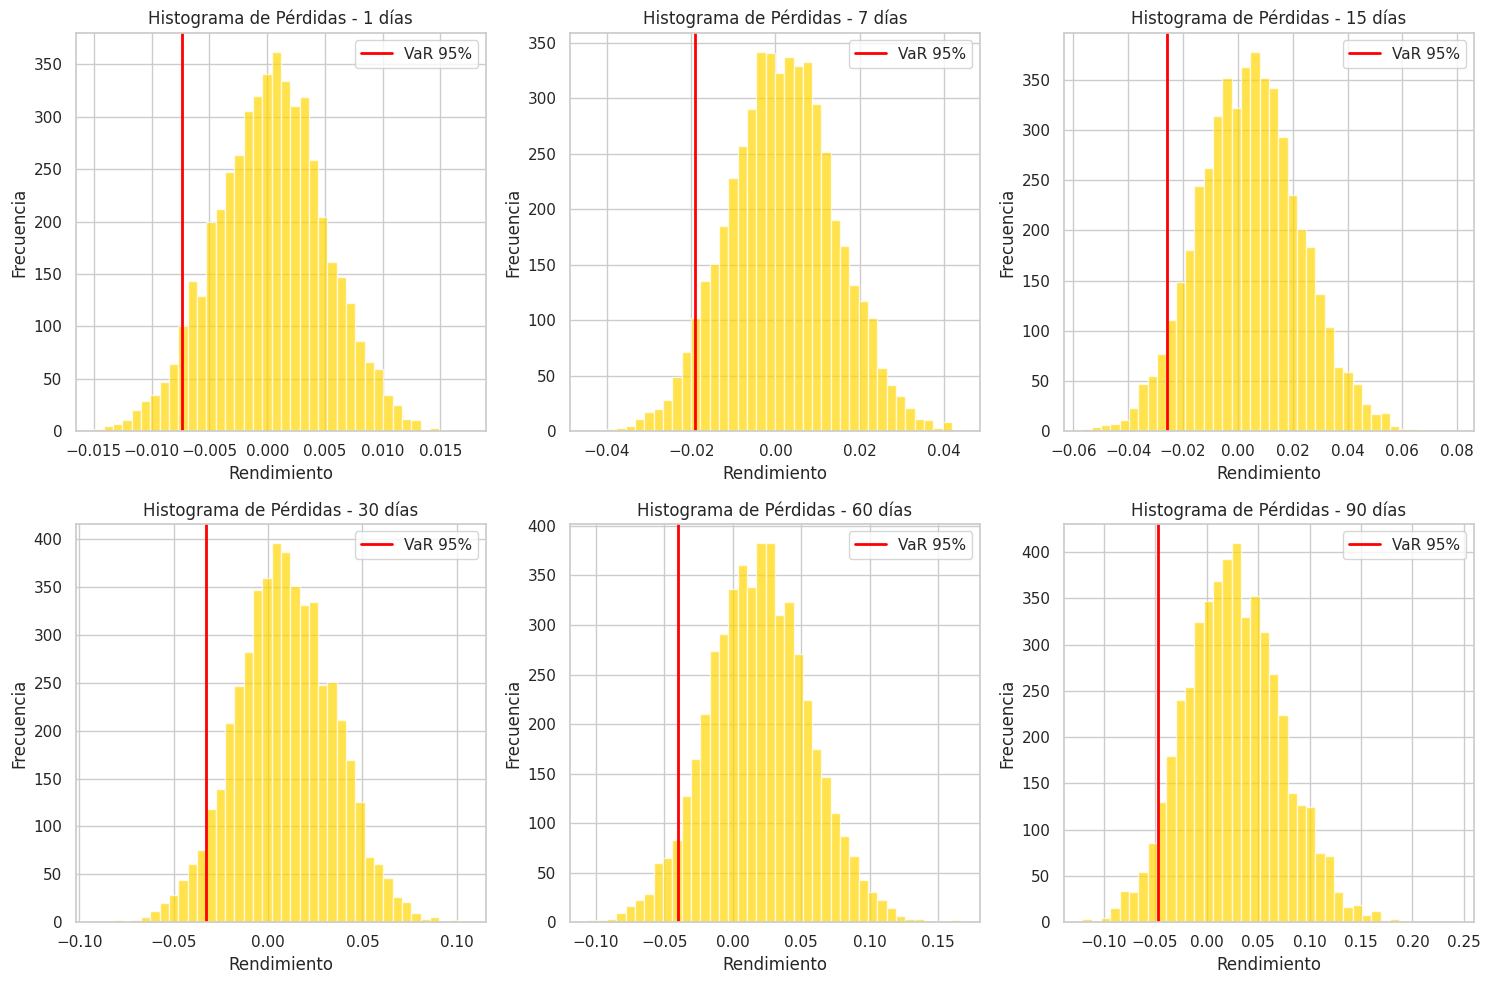

In [ ]:

# Cargar los datos desde el archivo Excel
cartera = pd.read_excel('cartera.xlsx', sheet_name='Sheet1')

# Número de días
n = len(cartera)

# Cálculo de rendimientos
d2_RendSMN = cartera.pct_change().dropna()

# Estimación de parámetros (media y desviación estándar)
mus = d2_RendSMN.mean()
sigmas = d2_RendSMN.std()

m = 5000  # Número de simulaciones
t = [1, 7, 15, 30, 60, 90]  # Horizontes
nc = [0.95, 0.97, 0.99]  # Niveles de confianza

# Inicialización de simulaciones
SMN_simulaciones = np.zeros((m, len(t)))

# Pesos del portafolio (asumimos pesos iguales)
pesos = np.ones(len(cartera.columns)) / len(cartera.columns)

# Realizar simulaciones
for j in range(m):
    for h in range(len(t)):
        horizonte = t[h]

        # Generar simulaciones de rendimientos para cada emisora
        rend_simulados = np.random.normal(mus, sigmas, (horizonte, len(cartera.columns)))

        # Calcular el rendimiento total del portafolio
        rend_portafolio_dia = np.dot(rend_simulados, pesos)
        rendSMN_portafolio = np.prod(1 + rend_portafolio_dia) - 1

        SMN_simulaciones[j, h] = rendSMN_portafolio

# Calcular VaR para cada nivel de confianza
resultados_VaRSMNport = np.percentile(SMN_simulaciones, [100 * (1 - c) for c in nc], axis=0)

# Calcular Expected Shortfall (ES) para cada nivel de confianza
ESs_portafolio = np.zeros((len(nc), len(t)))

for i in range(len(nc)):
    for h in range(len(t)):
        VaR_h = resultados_VaRSMNport[i, h]
        ESs_portafolio[i, h] = np.mean(SMN_simulaciones[SMN_simulaciones[:, h] > VaR_h, h])

# Mostrar resultados de VaR y ES
print("\n--- VaR Simulación Monte Carlo (Normal) ---")
print(pd.DataFrame(resultados_VaRSMNport, index=[f"VaR {int(c * 100)}%" for c in nc], columns=[f"{h} días" for h in t]))

print("\n--- Expected Shortfall (ES) ---")
print(pd.DataFrame(ESs_portafolio, index=[f"ES {int(c * 100)}%" for c in nc], columns=[f"{h} días" for h in t]))

# Graficar histogramas de simulaciones de pérdidas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    ax.hist(SMN_simulaciones[:, i], bins=40, color='gold', alpha=0.7)
    ax.axvline(resultados_VaRSMNport[0, i], color='red', linewidth=2, label=f'VaR {int(nc[0]*100)}%')
    ax.set_title(f"Histograma de Pérdidas - {t[i]} días")
    ax.set_xlabel("Rendimiento")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
plt.show()


### VaR no paramétrico Simulación Monte Carlo - Laplace
***- Individual***

Resultados VaR para la emisora: AAPL
                95%         97%         99%
1 días    -6.670522   -7.798239  -10.806828
7 días   -17.648543  -20.632201  -28.592178
15 días  -25.834822  -30.202450  -41.854663
30 días  -36.535955  -42.712715  -59.191432
60 días  -51.669643  -60.404901  -83.709326
90 días  -63.282131  -73.980592 -102.522568
180 días -89.494448 -104.624357 -144.988806


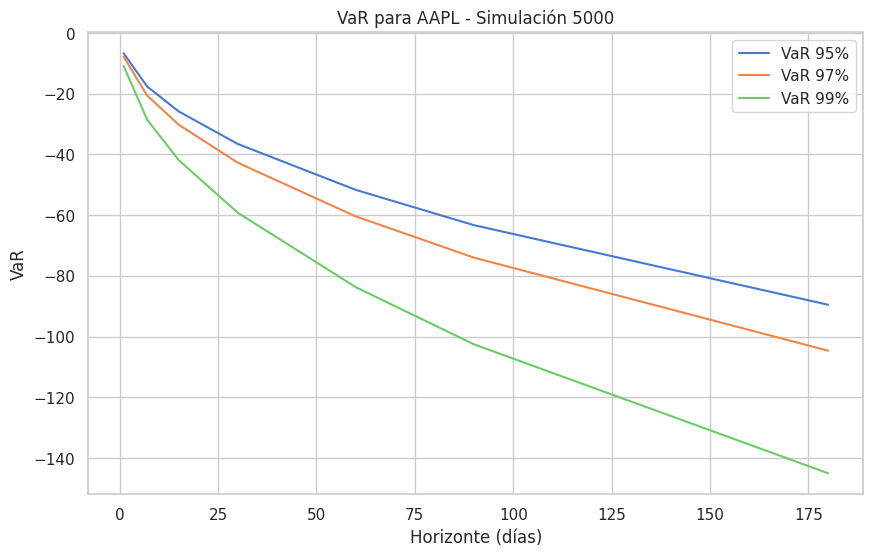

In [ ]:
# Cargar datos desde un archivo Excel (ajusta la ruta según corresponda)
cartera = pd.read_excel('cartera.xlsx', sheet_name='Sheet1')

# Calcular rendimientos logarítmicos
rendimientos = {}
for emisora in cartera.columns:
    precios_vec = cartera[emisora].values
    rend = np.diff(np.log(precios_vec))
    rendimientos[emisora] = rend

# Niveles de confianza y horizontes
nc = [0.95, 0.97, 0.99]
dias = [1, 7, 15, 30, 60, 90, 180]
nsim = [5000, 10000, 20000]

# Inicializar diccionarios para los resultados de VaR y ES
resultado_VaR = {}
resultado_ES = {}

# Para cada emisora
for emisora in cartera.columns:
    y = rendimientos[emisora]  # Rendimientos
    # Ajuste de Laplace
    loc, scale = laplace.fit(y)

    ultimo_precio = cartera[emisora].iloc[-1]  # Último precio disponible

    # Sublistas para cada emisora
    resultado_VaR[emisora] = {}
    resultado_ES[emisora] = {}

    for n_sims in nsim:
        # Simulación de rendimientos con distribución Laplace
        rend_sim = laplace.rvs(loc, scale, size=n_sims)
        precios_sim = ultimo_precio * np.exp(rend_sim)  # Simulación de precios futuros
        PL = ultimo_precio - precios_sim  # Pérdidas y ganancias

        # Guardar resultados de VaR y ES
        VaR_n = np.zeros((len(dias), len(nc)))
        ES_n = np.zeros((len(dias), len(nc)))

        for h_idx, h_day in enumerate(dias):
            escalar = np.sqrt(h_day)

            for c_idx, nivel in enumerate(nc):
                PL_esc = PL * escalar

                VaR_temp = np.percentile(PL_esc, 100 * (1 - nivel))  # VaR
                ES_temp = np.mean(PL_esc[PL_esc > VaR_temp])  # Expected Shortfall

                VaR_n[h_idx, c_idx] = VaR_temp
                ES_n[h_idx, c_idx] = ES_temp

        resultado_VaR[emisora][f"Sim_{n_sims}"] = VaR_n
        resultado_ES[emisora][f"Sim_{n_sims}"] = ES_n

# Visualizar los resultados del VaR para una emisora específica (ejemplo: AAPL)
emisora_ejemplo = 'AAPL'  # Cambia esto por la emisora que deseas visualizar
print("Resultados VaR para la emisora:", emisora_ejemplo)
print(pd.DataFrame(resultado_VaR[emisora_ejemplo]["Sim_5000"],
                   index=[f"{h} días" for h in dias],
                   columns=[f"{int(c * 100)}%" for c in nc]))

# Graficar los resultados de VaR para la emisora seleccionada
plt.figure(figsize=(10, 6))
for nivel in nc:
    plt.plot(dias, resultado_VaR[emisora_ejemplo]["Sim_5000"][:, nc.index(nivel)], label=f"VaR {int(nivel*100)}%")
plt.title(f'VaR para {emisora_ejemplo} - Simulación 5000')
plt.xlabel('Horizonte (días)')
plt.ylabel('VaR')
plt.legend()
plt.grid(True)
plt.show()


Visualización del **VaR** y **Expected Shortfall** para una emisora con m simulaciones

In [ ]:
# Mostrar resultados VaR y ES para AAPL, Sim_5000
print("Resultados VaR para AAPL (Sim_5000):")
print(pd.DataFrame(resultado_VaR["AAPL"]["Sim_5000"],
                   index=[f"{h} días" for h in dias],
                   columns=[f"{int(c * 100)}%" for c in nc]))

print("\nResultados Expected Shortfall (ES) para AAPL (Sim_5000):")
print(pd.DataFrame(resultado_ES["AAPL"]["Sim_5000"],
                   index=[f"{h} días" for h in dias],
                   columns=[f"{int(c * 100)}%" for c in nc]))


Resultados VaR para AAPL (Sim_5000):
                95%         97%         99%
1 días    -6.670522   -7.798239  -10.806828
7 días   -17.648543  -20.632201  -28.592178
15 días  -25.834822  -30.202450  -41.854663
30 días  -36.535955  -42.712715  -59.191432
60 días  -51.669643  -60.404901  -83.709326
90 días  -63.282131  -73.980592 -102.522568
180 días -89.494448 -104.624357 -144.988806

Resultados Expected Shortfall (ES) para AAPL (Sim_5000):
               95%       97%       99%
1 días    0.266674  0.112569 -0.073447
7 días    0.705553  0.297830 -0.194321
15 días   1.032824  0.435979 -0.284457
30 días   1.460633  0.616567 -0.402283
60 días   2.065648  0.871958 -0.568914
90 días   2.529891  1.067926 -0.696775
180 días  3.577807  1.510275 -0.985389


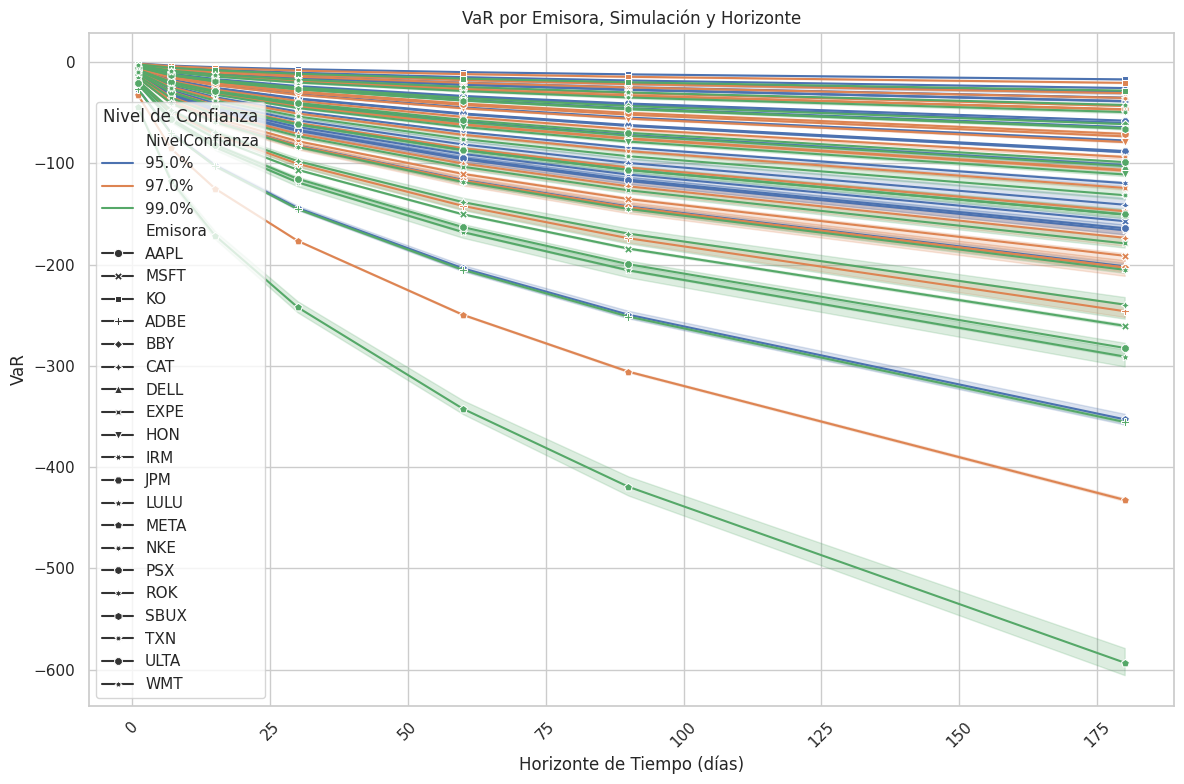

In [ ]:

# Cargar el archivo Excel
cartera = pd.read_excel('/content/cartera.xlsx', sheet_name='Sheet1')

# Crear un DataFrame vacío para almacenar los resultados
df_VaR = pd.DataFrame()

# Suponiendo que `resultado_VaR`, `nsim`, `dias` y `nc` ya están definidos
for emisora in cartera.columns:  # Se asume que cada columna es una emisora
    for n_sims in nsim:
        for h in range(len(dias)):
            for c in range(len(nc)):
                # Obtener el valor de VaR
                VaR_value = resultado_VaR[emisora][f"Sim_{n_sims}"][h, c]

                # Agregar los datos al DataFrame
                df_VaR = pd.concat([df_VaR, pd.DataFrame({
                    'Emisora': [emisora],
                    'Simulacion': [n_sims],
                    'Horizonte': [dias[h]],
                    'NivelConfianza': [f'{nc[c]*100}%'],
                    'VaR': [VaR_value]
                })], ignore_index=True)

# Configurar el estilo de las gráficas
sns.set(style="whitegrid")

# Crear la gráfica
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_VaR, x='Horizonte', y='VaR', hue='NivelConfianza',
             style='Emisora', markers=True, dashes=False)

# Ajustar el formato de la gráfica
plt.title('VaR por Emisora, Simulación y Horizonte')
plt.xlabel('Horizonte de Tiempo (días)')
plt.ylabel('VaR')
plt.xticks(rotation=45)
plt.legend(title='Nivel de Confianza')

# Mostrar la gráfica
plt.tight_layout()
plt.show()


***- Portafolio***

In [ ]:

# Cargar el archivo Excel
cartera = pd.read_excel('/content/cartera.xlsx', sheet_name='Sheet1')

# Simulación de precios (equivalente a 'precios <- list()' en R)
precios = {}
for emisora in cartera.columns:  # Se asume que cada columna es una emisora
    precios[emisora] = cartera[emisora].values  # Precios de cierre ajustados

# Rendimientos logarítmicos (equivalente a 'rendimientos <- list()' en R)
rendimientos = {}
for emisora in cartera.columns:
    precios_vec = precios[emisora]
    rend = np.diff(np.log(precios_vec))  # Rendimiento logarítmico
    rendimientos[emisora] = rend

# Parámetros
nc = [0.95, 0.97, 0.99]  # Niveles de confianza
dias = [1, 7, 15, 30, 60, 90, 180]  # Horizontes de tiempo
nsim = [5000, 10000, 20000]  # Número de simulaciones
np.random.seed(123)

# Inicializar los resultados para el portafolio
resultado_VaR_portafolio = {}
resultado_ES_portafolio = {}

# Pesos iguales
pesos = np.ones(len(cartera.columns)) / len(cartera.columns)

# Rendimiento del portafolio
rend_portafolio = sum([rendimientos[emisora] * pesos[i] for i, emisora in enumerate(cartera.columns)])

# Ajuste de distribución Laplace (equivalente a 'fitdist' en R)
loc_port, scale_port = laplace.fit(rend_portafolio)

# Últimos precios
ultimos_precios = {emisora: precios[emisora][-1] for emisora in cartera.columns}

# Último precio del portafolio
ultimo_precio_portafolio = sum(pesos * np.array(list(ultimos_precios.values())))

# Simulaciones
for n_sims in nsim:
    # Simular los rendimientos del portafolio
    rend_sim_portafolio = laplace.rvs(loc=loc_port, scale=scale_port, size=n_sims)
    precios_sim_portafolio = ultimo_precio_portafolio * np.exp(rend_sim_portafolio)
    PL_portafolio = ultimo_precio_portafolio - precios_sim_portafolio

    VaR_n_port = np.zeros((len(dias), len(nc)))
    ES_n_port = np.zeros((len(dias), len(nc)))

    for h, h_day in enumerate(dias):
        escalar = np.sqrt(h_day)

        for c, nivel in enumerate(nc):
            # Escalar los P&L
            PL_esc = PL_portafolio * escalar

            # Calcular VaR y ES
            VaR_temp = np.percentile(PL_esc, nivel * 100)
            ES_temp = np.mean(PL_esc[PL_esc > VaR_temp])

            VaR_n_port[h, c] = VaR_temp
            ES_n_port[h, c] = ES_temp

    resultado_VaR_portafolio[f"Sim_{n_sims}"] = VaR_n_port
    resultado_ES_portafolio[f"Sim_{n_sims}"] = ES_n_port

# Aquí puedes guardar o procesar los resultados como desees


Visualización del **VaR** y **Expected Shortfall** para una emisora con m simulaciones del portafolio

In [ ]:

# Crear un DataFrame vacío para almacenar los resultados
df_resultados = pd.DataFrame()

# Iterar sobre las simulaciones
for n_sims in nsim:
    VaR_temp = resultado_VaR_portafolio[f"Sim_{n_sims}"]
    ES_temp  = resultado_ES_portafolio[f"Sim_{n_sims}"]

    # Iterar sobre los horizontes de tiempo y niveles de confianza
    for h, horizonte in enumerate(dias):
        for c, nivel_confianza in enumerate(nc):
            fila_temp = pd.DataFrame({
                'Simulacion': [n_sims],
                'Horizonte': [horizonte],
                'NivelConfianza': [nivel_confianza],
                'VaR': [VaR_temp[h, c]],
                'ES': [ES_temp[h, c]]
            })

            # Concatenar la fila al DataFrame
            df_resultados = pd.concat([df_resultados, fila_temp], ignore_index=True)

# Ver las primeras filas del DataFrame resultante
print(df_resultados.head())


   Simulacion  Horizonte  NivelConfianza        VaR         ES
0        5000          1            0.95   4.644171   6.654066
1        5000          1            0.97   5.750947   7.655094
2        5000          1            0.99   7.924953   9.783529
3        5000          7            0.95  12.287321  17.605005
4        5000          7            0.97  15.215574  20.253476


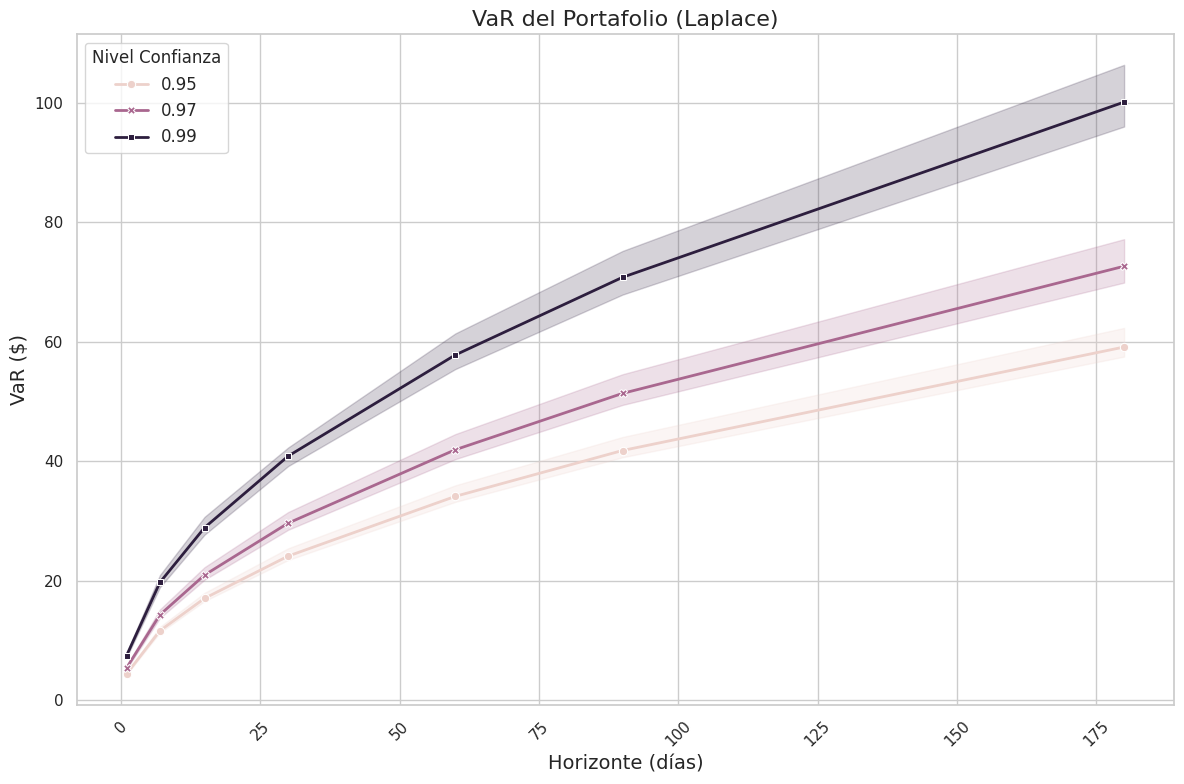

In [ ]:

# Establecer el estilo de los gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Crear la gráfica
plt.figure(figsize=(12, 8))

# Crear la gráfica de líneas con facetado por simulación
sns.lineplot(data=df_resultados, x='Horizonte', y='VaR', hue='NivelConfianza',
             style='NivelConfianza', markers=True, dashes=False, linewidth=2)

# Agregar títulos y etiquetas
plt.title('VaR del Portafolio (Laplace)', fontsize=16)
plt.xlabel('Horizonte (días)', fontsize=14)
plt.ylabel('VaR ($)', fontsize=14)

# Rotar etiquetas del eje X
plt.xticks(rotation=45)

# Mostrar la leyenda
plt.legend(title='Nivel Confianza', fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


# **VaR paramétrico**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

d1 = pd.read_excel('/content/cartera.xlsx')
d1.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,AAPL,MSFT,KO,ADBE,BBY,CAT,DELL,EXPE,HON,IRM,JPM,LULU,META,NKE,PSX,ROK,SBUX,TXN,ULTA,WMT
0,182.009995,334.750000,59.299999,564.369995,102.120003,207.000000,56.980000,184.970001,206.800003,51.320000,161.699997,387.559998,338.540009,164.669998,75.739998,339.660004,116.680000,190.600006,413.230011,48.216667
1,179.699997,329.010010,60.290001,554.000000,105.139999,218.080002,58.490002,185.369995,209.000000,50.750000,167.830002,380.820007,336.529999,166.389999,78.570000,343.100006,114.239998,190.800003,418.739990,47.333332
2,174.919998,316.380005,60.790001,514.429993,103.000000,219.750000,57.980000,181.300003,211.059998,48.500000,163.779999,362.480011,324.170013,162.250000,78.320000,337.359985,110.440002,186.820007,401.489990,47.973331
3,172.000000,313.880005,60.470001,514.119995,102.879997,221.990005,58.040001,177.580002,210.820007,46.770000,165.520004,368.769989,332.459991,161.039993,80.480003,335.109985,111.139999,186.759995,400.489990,47.840000
4,172.169998,314.040009,60.330002,510.700012,102.500000,224.190002,57.990002,179.910004,215.750000,46.790001,167.160004,355.209991,331.790009,156.970001,81.959999,327.880005,107.570000,179.440002,397.100006,48.296665


## **VaR Parametrico: Individual**

In [ ]:
import numpy as np

from scipy.stats import norm

n = 20
m = len(d1)

# Inicializar matrices
rend = np.empty((m - 1, n))
reval = np.empty((m - 1, n))
pl = np.empty((m - 1, n))

# Cálculo de rendimientos, precios revaluados y pérdidas/ganancias
for j in range(n):
    for k in range(1, m):
        rend[k - 1, j] = d1.iloc[k, j] / d1.iloc[k - 1, j] - 1
        reval[k - 1, j] = d1.iloc[m - 1, j] * (1 + rend[k - 1, j])
        pl[k - 1, j] = d1.iloc[m - 1, j] - reval[k - 1, j]

# VaR Paramétrico Individual
conf = [0.95, 0.97, 0.99]
f = norm.ppf(conf, loc=0, scale=1)
t = [1, 7, 15, 30, 60, 90, 180]

VaRp = np.empty((n, len(f), len(t)))

for j in range(n):
    sigma = np.std(rend[:, j], ddof=1)
    for i in range(len(f)):
        for h in range(len(t)):
            VaRp[j, i, h] = d1.iloc[m - 1, j] * f[i] * sigma * np.sqrt(t[h])


# **VaR Parametrico: Individual. Horizonte de tiempo de 1 dia, nivel de confianza del 95%, 95% y 99%**

In [ ]:
# Mostrar el VaR para horizonte de 1 día
VaRp_1d = VaRp[:, :, 0]
VaRp_1d_df = pd.DataFrame(VaRp_1d, columns=['VaR_95%', 'VaR_97%', 'VaR_99%'])
VaRp_1d_df.index = d1.columns[:n]  # Suponiendo que n = número de emisoras
VaRp_1d_df


,VaR_95%,VaR_97%,VaR_99%
AAPL,6.147449,7.029247,8.694454
MSFT,10.778286,12.324338,15.243936
KO,1.167463,1.334925,1.651165
ADBE,15.280428,17.472273,21.611401
BBY,2.708767,3.097316,3.831061
CAT,10.044779,11.485615,14.206522
DELL,4.505388,5.151647,6.372056
EXPE,7.815382,8.936431,11.053444
HON,4.498242,5.143476,6.361949
IRM,2.596543,2.968995,3.672341


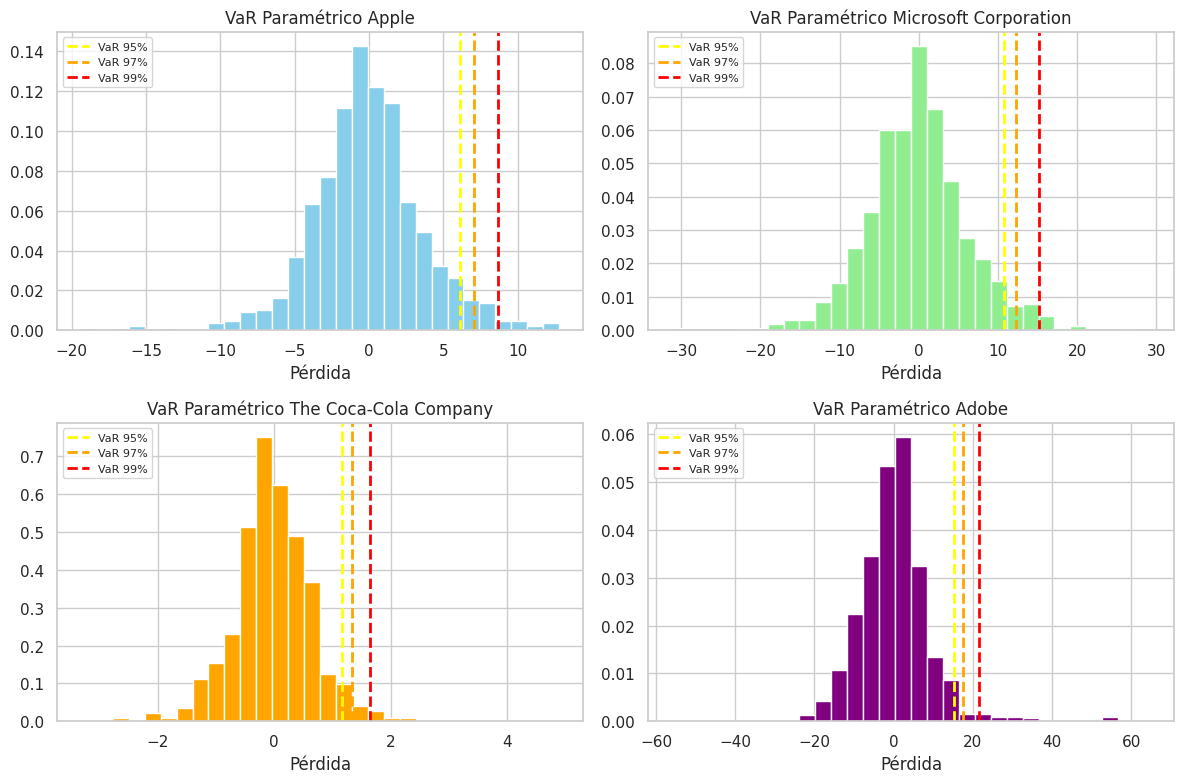

In [ ]:
import matplotlib.pyplot as plt

emisoras = d1.columns[:4]
colores = ["skyblue", "lightgreen", "orange", "purple"]
niveles_conf = [0.95, 0.97, 0.99]
col_var = ["yellow", "orange", "red"]
titulos = ["VaR Paramétrico Apple", "VaR Paramétrico Microsoft Corporation",
           "VaR Paramétrico The Coca-Cola Company", "VaR Paramétrico Adobe"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for j in range(4):
    datos = pl[:, j]  # pérdidas y ganancias simuladas para cada emisora
    axs[j].hist(datos, bins=30, color=colores[j], density=True)
    axs[j].set_title(titulos[j])
    axs[j].set_xlabel("Pérdida")

    # Dibujar líneas de VaR (plazo 1 día)
    for i in range(3):
        axs[j].axvline(VaRp[j, i, 0], color=col_var[i], linestyle='--', linewidth=2)

    axs[j].legend(["VaR 95%", "VaR 97%", "VaR 99%"], loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


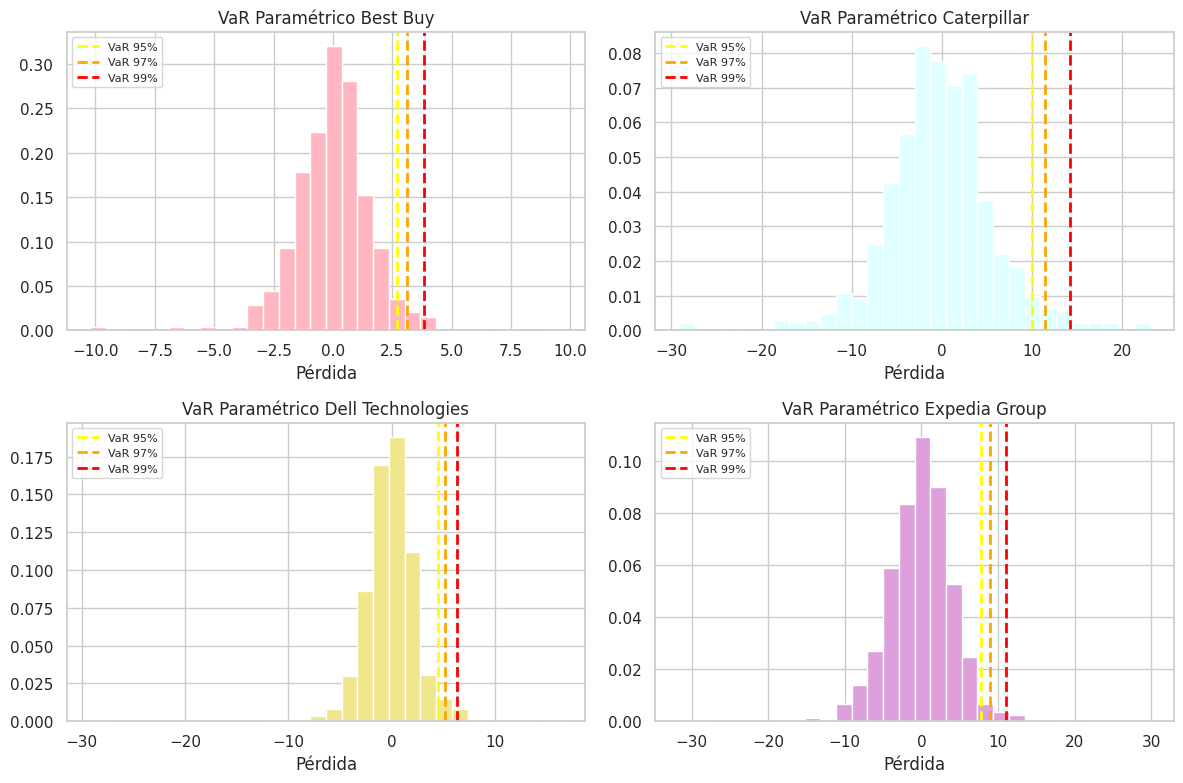

In [ ]:
emisoras = d1.columns[4:8]
colores = ["lightpink", "lightcyan", "khaki", "plum"]
niveles_conf = [0.95, 0.97, 0.99]
col_var = ["yellow", "orange", "red"]
titulos = ["VaR Paramétrico Best Buy", "VaR Paramétrico Caterpillar",
           "VaR Paramétrico Dell Technologies", "VaR Paramétrico Expedia Group"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for j in range(4):
    datos = pl[:, j + 4]
    axs[j].hist(datos, bins=30, color=colores[j], density=True)
    axs[j].set_title(titulos[j])
    axs[j].set_xlabel("Pérdida")

    for i in range(3):
        axs[j].axvline(VaRp[j + 4, i, 0], color=col_var[i], linestyle='--', linewidth=2)

    axs[j].legend(["VaR 95%", "VaR 97%", "VaR 99%"], loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


## **VaR Parametrico: Portafolio**

In [ ]:
import numpy as np
import pandas as pd

# Suponiendo que `d1` es un DataFrame (rendimientos diarios)
n = d1.shape[1]
m = d1.shape[0]

acciones = np.repeat(1000, n)

# Multiplicar rendimientos por número de acciones
d2 = np.zeros((m, n))
for j in range(n):
    d2[:, j] = d1.iloc[:, j] * acciones[j]

# Pesos del portafolio basados en el último valor de cada acción
q = d2[-1, :] / d2[-1, :].sum()


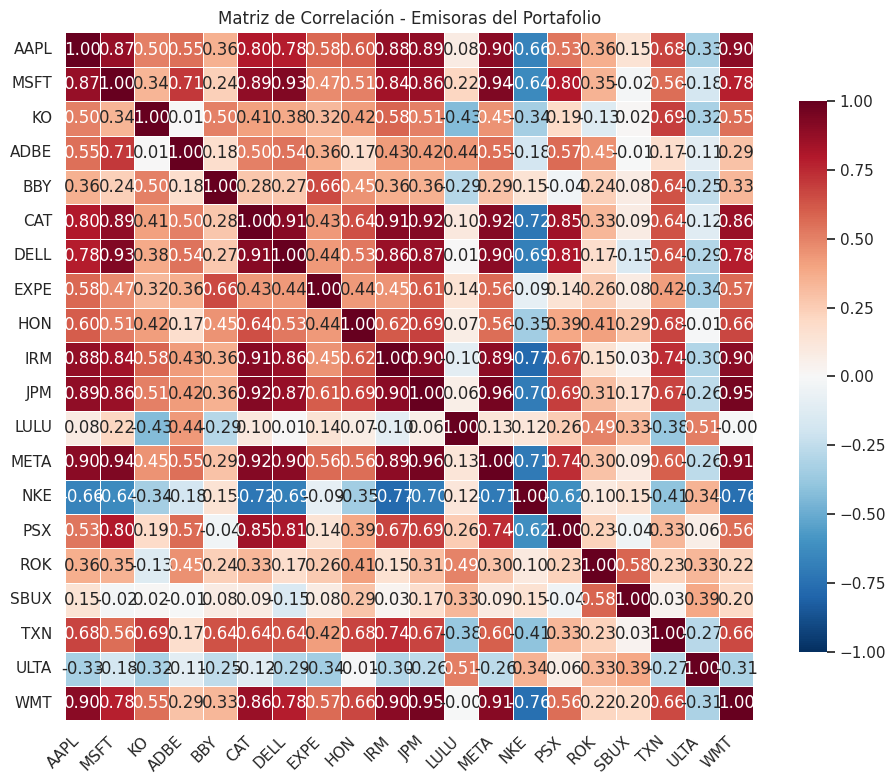

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de varianzas y correlaciones
rend = d1  # Rendimientos diarios de cada acción
c = rend.cov()
cc = rend.corr()

# Gráfico tipo corrplot (correlaciones)
plt.figure(figsize=(10, 8))
sns.heatmap(cc, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlación - Emisoras del Portafolio")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## **Conlusiones:**

Correlaciones más fuertes (positivas):

Tecnología:

MSFT (2) y AAPL (1): 0.36 (moderada, menor de lo esperado para empresas tech).

DELL (7) y BBY (5): 0.67 (alta, posiblemente por solapamiento en ventas de hardware).

Consumo Discrecional:

NKE (14) y LULU (12): 0.43 (moderada, ambas en ropa/deportes).

ULTA (19) y WMT (20): 0.54 (alta, sorprendente para retail de cosméticos vs. supermercados).

Correlaciones débiles o negativas:

KO (3) (Coca-Cola) muestra correlaciones bajas con casi todo (ej. 0.11 con MSFT), típico de acciones defensivas.

IRM (10) (almacenamiento) tiene correlaciones modestas (ej. 0.33 con JPM), reflejando su naturaleza aislada.

Patrones inesperados:

PSX (15) (energía) tiene correlación 0.44 con WMT (20) (retail), quizás por dinámicas inflacionarias.

JPM (11) (banca) y KO (3): 0.51 (alta para sectores distintos, posiblemente por dividendos).




In [ ]:
import numpy as np
from scipy.stats import norm

# Aseguramos q como matriz columna
q = q.reshape(-1, 1)

# Varianza del portafolio
varianza_port = float(q.T @ c.values @ q)
volatilidad_port = np.sqrt(varianza_port)

# Supuestos de niveles de confianza y horizontes de tiempo
f = np.array([norm.ppf(0.95), norm.ppf(0.97), norm.ppf(0.99)])
t = np.array([1, 7, 15, 30, 60, 90, 180])

# VaR portafolio (dim: [len(f), len(t)])
VaR_port = np.zeros((len(f), len(t)))

# VaR individual (dim: [n, len(f), len(t)])
VaR_ind = np.zeros((n, len(f), len(t)))

# Cálculos
total_valor_portafolio = np.sum(d2[-1, :])

for i in range(len(f)):
    for k in range(len(t)):
        # VaR del portafolio
        VaR_port[i, k] = total_valor_portafolio * f[i] * volatilidad_port * np.sqrt(t[k])

        # VaR individual
        for j in range(n):
            VaR_ind[j, i, k] = VaRp[j, i, k] * acciones[j]

# Sumar VaR individual para cada combinación de f y t
suma_VaR_ind = np.sum(VaR_ind, axis=0)  # dim: [len(f), len(t)]


<ipython-input-65-229a7fb80d1f>:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  varianza_port = float(q.T @ c.values @ q)


# **VaR Parametrico: Portafolio. Horizonte de tiempo de 1, 7, 15, 30, 60, 90, 180 dias, nivel de confianza del 95%, 95% y 99% **

In [ ]:
# Mostrar como DataFrame
import pandas as pd

niveles_conf = ['95%', '97%', '99%']
horizontes = [f"{dias} días" for dias in t]

VaR_port_df = pd.DataFrame(VaR_port, index=niveles_conf, columns=horizontes)
print("VaR Paramétrico del Portafolio (en pesos):")
print(VaR_port_df)


VaR Paramétrico del Portafolio (en pesos):
           1 días        7 días       15 días       30 días       60 días  \
95%  3.301627e+08  8.735284e+08  1.278715e+09  1.808376e+09  2.557429e+09   
97%  3.775217e+08  9.988285e+08  1.462135e+09  2.067771e+09  2.924270e+09   
99%  4.669554e+08  1.235448e+09  1.808511e+09  2.557620e+09  3.617021e+09   

          90 días      180 días  
95%  3.132198e+09  4.429597e+09  
97%  3.581485e+09  5.064985e+09  
99%  4.429928e+09  6.264864e+09  


# VaR Delta Normal: Individual

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Datos de entrada
conf = [0.05, 0.03, 0.01]
f = norm.ppf(conf, 0, 1)
t = [1, 7, 15, 30, 60, 90, 180]

n = 20  # Número de emisoras
m = len(d1)  # Número total de observaciones en d1
acciones = 1000

# Crear el array 3D: emisoras x niveles de confianza x plazos
VaRDN = np.full((n, len(f), len(t)), np.nan)

# Cálculo del VaR Delta Normal
for j in range(n):
    # Asegúrate de que rend esté indexado correctamente
    media = np.nanmean(rend.iloc[:, j])  # Media de los rendimientos
    vol = np.nanstd(rend.iloc[:, j])  # Volatilidad de los rendimientos
    precio_actual = d1.iloc[-1, j]  # Último precio de cada emisora

    for i in range(len(f)):
        for k in range(len(t)):
            VaRDN[j, i, k] = (acciones * precio_actual *
                              (media * t[k] + vol * f[i] * np.sqrt(t[k])))




# **VaR Delta Normal: Individual. Horizonte de tiempo de 1 dia, nivel de confianza del 95%, 95% y 99% **


In [ ]:
# VaR Delta Normal para el horizonte de 1 día (índice 0)
print(VaRDN[:, :, 0])

[[ 2.84299722e+07  2.68151703e+07  2.37657426e+07]
 [ 8.49036455e+07  7.86141531e+07  6.67369369e+07]
 [ 3.94072783e+06  3.87810954e+06  3.75985979e+06]
 [ 1.22101608e+08  1.14171652e+08  9.91965462e+07]
 [ 4.71204705e+06  4.54508261e+06  4.22978328e+06]
 [ 5.38885801e+07  4.86292991e+07  3.86975568e+07]
 [ 1.64100714e+06  8.81728555e+05 -5.52109876e+05]
 [ 1.28318745e+07  1.15003547e+07  8.98588337e+06]
 [ 3.75475864e+07  3.69007612e+07  3.56792822e+07]
 [ 2.67565698e+06  2.20786842e+06  1.32448619e+06]
 [ 2.29756852e+07  2.04826148e+07  1.57746455e+07]
 [ 7.40493667e+07  7.00162347e+07  6.23999793e+07]
 [ 3.50769646e+07  1.18820959e+07 -3.19196058e+07]
 [ 4.49527605e+06  4.20249023e+06  3.64958704e+06]
 [ 9.43089801e+06  8.80584082e+06  7.62546903e+06]
 [ 5.83521776e+07  5.66150254e+07  5.33345490e+07]
 [ 7.50468812e+06  7.27271301e+06  6.83464610e+06]
 [ 2.66574915e+07  2.60206755e+07  2.48180982e+07]
 [ 1.19797178e+08  1.15032528e+08  1.06034857e+08]
 [ 2.76564071e+06  2.44674742e+

## **VaR por Delta Normal: Portafolio**

In [ ]:
import numpy as np
from scipy.stats import norm

# Datos de entrada
conf = [0.05, 0.03, 0.01]
f = norm.ppf(conf, 0, 1)
t = [1, 7, 15, 30, 60, 90, 180]

n = 20  # Número de emisoras
m = len(d1)  # Número total de observaciones en d1
acciones = 1000
vol_p = volatilidad_port  # Volatilidad del portafolio
medias = np.nanmean(rend, axis=0)  # Media de los rendimientos
mu_p = np.dot(medias, q)  # Cálculo de la media ponderada del portafolio

# Precio actual y valor total del portafolio
precio_actual = d1.iloc[-1, :n].values  # Últimos precios de las emisoras
valor_portafolio = np.sum(precio_actual * acciones)

# Inicializar array de VaR del portafolio
VaR_port = np.full((len(f), len(t)), np.nan)

# Calcular VaR del portafolio
for i in range(len(f)):
    for k in range(len(t)):
        VaR_port[i, k] = -valor_portafolio * (mu_p * t[k] + vol_p * f[i] * np.sqrt(t[k]))

# Imprimir VaR del portafolio
print(VaR_port)


[[-8.21821919e+08 -7.19036395e+09 -1.60010547e+10 -3.27511631e+10
  -6.65616480e+10 -1.00546418e+11 -2.02927635e+11]
 [-7.74462944e+08 -7.06506388e+09 -1.58176342e+10 -3.24917673e+10
  -6.61948070e+10 -1.00097131e+11 -2.02292247e+11]
 [-6.85029210e+08 -6.82844446e+09 -1.54712588e+10 -3.20019185e+10
  -6.55020563e+10 -9.92486880e+10 -2.01092368e+11]]


<ipython-input-69-a2d1f54d5080>:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  VaR_port[i, k] = -valor_portafolio * (mu_p * t[k] + vol_p * f[i] * np.sqrt(t[k]))


# **VaR Delta Normal: Portafolio. Horizonte de tiempo de 1, 7, 15, 30, 60, 90, 180 dias, nivel de confianza del 95%, 95% y 99% **

In [ ]:
# Imprimir VaR del portafolio
print(VaR_port)

[[-8.21821919e+08 -7.19036395e+09 -1.60010547e+10 -3.27511631e+10
  -6.65616480e+10 -1.00546418e+11 -2.02927635e+11]
 [-7.74462944e+08 -7.06506388e+09 -1.58176342e+10 -3.24917673e+10
  -6.61948070e+10 -1.00097131e+11 -2.02292247e+11]
 [-6.85029210e+08 -6.82844446e+09 -1.54712588e+10 -3.20019185e+10
  -6.55020563e+10 -9.92486880e+10 -2.01092368e+11]]


## **VaR por Expansion Cornish Fisher: Individual**

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, norm

# Parámetros de entrada
conf = [0.05, 0.03, 0.01]
z = norm.ppf(conf, 0, 1)
t = [1, 7, 15, 30, 60, 90, 180]
acciones = 1000

n = 20
m = len(d1)

# Inicializar array 3D para almacenar resultados
VaR_CF = np.full((n, len(conf), len(t)), np.nan)

# Calcular VaR Cornish-Fisher para cada emisora
for j in range(n):
    rend_emi = rend.iloc[:, j]
    media = np.nanmean(rend_emi)
    vol = np.nanstd(rend_emi)
    S = skew(rend_emi.dropna())
    K = kurtosis(rend_emi.dropna(), fisher=False)  # R devuelve la "kurtosis total"

    precio_actual = d1.iloc[-1, j]

    for i in range(len(z)):
        # Ajuste de Cornish-Fisher
        w = (z[i] +
             (z[i]**2 - 1) * (S / 6) +
             z[i] * (z[i]**2 - 3) * (K / 24) -
             z[i] * (2 * z[i]**2 - 5) * (S**2 / 36))

        for k in range(len(t)):
            VaR_CF[j, i, k] = -acciones * precio_actual * (media * t[k] + vol * w * np.sqrt(t[k]))

# Mostrar el VaR Cornish-Fisher para horizonte de 1 día (índice 0)
print(VaR_CF[:, :, 0])


[[-2.97303198e+07 -2.77508102e+07 -2.31835987e+07]
 [-8.58807110e+07 -7.70674111e+07 -5.73693216e+07]
 [-4.01215649e+06 -3.92243850e+06 -3.70007537e+06]
 [-1.22508925e+08 -1.09789791e+08 -8.04787123e+07]
 [-4.84104853e+06 -4.62383626e+06 -4.11611170e+06]
 [-5.67035879e+07 -5.01327658e+07 -3.53555051e+07]
 [-2.37223455e+06 -1.61172442e+06  6.80868543e+04]
 [-1.40981990e+07 -1.26822617e+07 -9.49692536e+06]
 [-3.78410362e+07 -3.67736294e+07 -3.42042128e+07]
 [-3.37300988e+06 -3.01932334e+06 -2.24923004e+06]
 [-2.58937014e+07 -2.34209278e+07 -1.78143505e+07]
 [-7.85351464e+07 -7.34568135e+07 -6.12538850e+07]
 [-5.06421430e+07 -2.30975498e+07  3.88507590e+07]
 [-4.65130908e+06 -4.20075335e+06 -3.12667821e+06]
 [-9.77558726e+06 -8.92103282e+06 -6.94279906e+06]
 [-5.79588421e+07 -5.40847864e+07 -4.46207093e+07]
 [-7.47026589e+06 -7.05092366e+06 -6.07014733e+06]
 [-2.70789665e+07 -2.61705075e+07 -2.40194553e+07]
 [-1.24848454e+08 -1.19745067e+08 -1.08072528e+08]
 [-3.36563828e+06 -3.17346307e+

# **VaR Expansion Cornish Fisher: Individual. Horizonte de tiempo de 1 dia, nivel de confianza del 95%, 95% y 99% **

In [ ]:
# Mostrar el VaR Cornish-Fisher para horizonte de 1 día (índice 0)
print(VaR_CF[:, :, 0])

[[-2.97303198e+07 -2.77508102e+07 -2.31835987e+07]
 [-8.58807110e+07 -7.70674111e+07 -5.73693216e+07]
 [-4.01215649e+06 -3.92243850e+06 -3.70007537e+06]
 [-1.22508925e+08 -1.09789791e+08 -8.04787123e+07]
 [-4.84104853e+06 -4.62383626e+06 -4.11611170e+06]
 [-5.67035879e+07 -5.01327658e+07 -3.53555051e+07]
 [-2.37223455e+06 -1.61172442e+06  6.80868543e+04]
 [-1.40981990e+07 -1.26822617e+07 -9.49692536e+06]
 [-3.78410362e+07 -3.67736294e+07 -3.42042128e+07]
 [-3.37300988e+06 -3.01932334e+06 -2.24923004e+06]
 [-2.58937014e+07 -2.34209278e+07 -1.78143505e+07]
 [-7.85351464e+07 -7.34568135e+07 -6.12538850e+07]
 [-5.06421430e+07 -2.30975498e+07  3.88507590e+07]
 [-4.65130908e+06 -4.20075335e+06 -3.12667821e+06]
 [-9.77558726e+06 -8.92103282e+06 -6.94279906e+06]
 [-5.79588421e+07 -5.40847864e+07 -4.46207093e+07]
 [-7.47026589e+06 -7.05092366e+06 -6.07014733e+06]
 [-2.70789665e+07 -2.61705075e+07 -2.40194553e+07]
 [-1.24848454e+08 -1.19745067e+08 -1.08072528e+08]
 [-3.36563828e+06 -3.17346307e+

## **VaR  por Expansion Cornish Fisher : Portafolio**

In [ ]:
import numpy as np
from scipy.stats import norm, skew, kurtosis

# Paso 1: pesos del portafolio
acciones = np.full(20, 1000)  # 1000 acciones por emisora
valores = d1.iloc[-1, :20].values * acciones  # precio actual * acciones
w = valores / np.sum(valores)  # pesos normalizados del portafolio

# Paso 2: rendimiento del portafolio
rend_port = rend.values @ q  # producto matriz rendimientos * ponderadores

# Paso 3: momentos del portafolio
media = np.nanmean(rend_port)
vol = np.nanstd(rend_port)
S = skew(rend_port[~np.isnan(rend_port)])
K = kurtosis(rend_port[~np.isnan(rend_port)], fisher=False)  # Curtosis total (como en R)

# Paso 4: VaR Cornish-Fisher
conf = [0.05, 0.03, 0.01]
z = norm.ppf(conf, 0, 1)
t = [1, 7, 15, 30, 60, 90, 180]
valor_portafolio = np.sum(valores)

VaR_CF_port = np.full((len(conf), len(t)), np.nan)

for i in range(len(z)):
    w_cf = (z[i] +
            (z[i]**2 - 1) * (S / 6) +
            z[i] * (z[i]**2 - 3) * (K / 24) -
            z[i] * (2 * z[i]**2 - 5) * (S**2 / 36))

    for j in range(len(t)):
        VaR_CF_port[i, j] = -valor_portafolio * (media * t[j] + vol * w_cf * np.sqrt(t[j]))




# **VaR por Expansion Cornish Fisher: Portafolio. Horizonte de tiempo de 1, 7, 15, 30, 60, 90, 180 dias, nivel de confianza del 95%, 95% y 99% **

In [ ]:
# Mostrar el resultado
print(VaR_CF_port)

[[-8.27582825e+08 -7.20560588e+09 -1.60233666e+10 -3.27827169e+10
  -6.66062718e+10 -1.00601070e+11 -2.03004925e+11]
 [-7.58922129e+08 -7.02394675e+09 -1.57574448e+10 -3.24066467e+10
  -6.60744284e+10 -9.99496978e+10 -2.02083745e+11]
 [-6.04379231e+08 -6.61506468e+09 -1.51589028e+10 -3.15601804e+10
  -6.48773442e+10 -9.84835751e+10 -2.00010335e+11]]


# **VaR no paramétrica**

### VaR no paramétrico Simulación Bootstrapping

#### Creacion de la base de datos

***- Individual***

In [ ]:
import numpy as np
import pandas as pd

# --- 1. Leer Excel ---
archivo = 'cartera.xlsx'
d1 = pd.read_excel(archivo, sheet_name='Sheet1', index_col=0)

# --- 2. Configuraciones ---
np.random.seed(123)

n = d1.shape[1]  # Número de emisoras
m = d1.shape[0]  # Número de observaciones
acciones = 1000
nsim = 5000

t_horizontes = [1, 7, 15, 30, 60, 90, 180]
conf = [0.95, 0.97, 0.99]

emisoras = d1.columns.tolist()

# --- 3. Calcular rendimientos históricos ---
rend = np.full((m-1, n), np.nan)

for j in range(n):
    for k in range(1, m):
        rend[k-1, j] = d1.iloc[k, j] / d1.iloc[k-1, j] - 1

# --- 4. Crear array 3D para guardar resultados ---
VaR_bootstrap_ind = np.full((n, len(conf), len(t_horizontes)), np.nan)

# --- 5. Simulación ---
for j in range(n):
    y = rend[:, j]  # rendimientos históricos de la emisora j
    precio_actual = d1.iloc[-1, j]

    for k, plazo in enumerate(t_horizontes):
        pl_sim = np.full((nsim, len(conf)), np.nan)

        for i in range(nsim):
            rend_sim = np.random.choice(y, size=len(y), replace=True)
            reval = precio_actual * (1 + rend_sim * np.sqrt(plazo))  # Ajustar por el plazo
            pl = precio_actual - reval  # pérdida o ganancia

            for c, nivel_conf in enumerate(conf):
                pl_sim[i, c] = np.quantile(pl, nivel_conf)

        VaR_bootstrap_ind[j, :, k] = np.nanmean(pl_sim, axis=0) * acciones

# --- 6. Mostrar un ejemplo ---
# Para horizonte de 1 día (t = 1)
import pandas as pd

# Crear DataFrame bonito para horizonte de 1 día
df_VaR_T1 = pd.DataFrame(VaR_bootstrap_ind[:, :, 0],
                         index=emisoras,
                         columns=[f'Conf_{int(c*100)}%' for c in conf])

print(df_VaR_T1.round(2))

# Si quieres todo el array VaR_bootstrap_ind puedes usar:
VaR_bootstrap_ind


      Conf_95%  Conf_97%  Conf_99%
MSFT  10652.55  13258.81  16480.46
KO     1082.90   1274.26   1821.56
ADBE  13191.79  16611.08  28604.31
BBY    2417.73   2926.89   3943.58
CAT    9276.33  11687.51  16299.80
DELL   3757.72   4604.78   6735.22
EXPE   6226.10   7777.23  12404.50
HON    4196.75   5048.58   7245.66
IRM    2352.93   3055.58   4490.82
JPM    6037.30   7603.29  10492.28
LULU  11152.38  13637.30  20952.52
META  23795.55  27287.54  39149.28
NKE    1986.76   2354.58   3650.15
PSX    3890.85   4833.39   6666.61
ROK    8177.44   9309.21  12951.75
SBUX   2573.83   3279.87   4587.72
TXN    5011.62   5866.43   7828.52
ULTA  11866.11  13604.97  17182.05
WMT    1605.23   1888.64   2877.12


array([[[ 10652.54623767,  28222.21081184,  41251.39634199,
          58369.07328865,  82553.69538778, 101033.99674108,
         143300.8625918 ],
        [ 13258.80656712,  35130.84586047,  51351.40183463,
          72779.55801055, 102764.91791718, 125673.68946338,
         178455.27133893],
        [ 16480.45728993,  43615.7210009 ,  63859.26434745,
          90545.27117286, 127730.93566154, 156474.94048168,
         221653.54893809]],

       [[  1082.90475267,   2860.81585566,   4194.30858605,
           5926.01544768,   8378.87278728,  10262.98500744,
          14502.60285965],
        [  1274.26346789,   3366.73268844,   4937.39278292,
           6968.99146325,   9853.44232171,  12072.61953863,
          17059.85392174],
        [  1821.55846854,   4804.33399164,   7062.09783891,
           9968.3397854 ,  14091.97497442,  17284.71567295,
          24403.31529537]],

       [[ 13191.78826625,  34893.77060209,  51055.34449456,
          72159.06910701, 102255.66897678, 125018.7649

***- Portafolio***


In [ ]:
import numpy as np
import pandas as pd

# --- Configuraciones ---
np.random.seed(123)

m = 1000  # Simulaciones externas
n_sim = 5000  # Simulaciones internas
horizontes = [1, 7, 15, 30, 60, 90, 180]
niveles_conf = [0.99, 0.97, 0.95]

acciones = 1000

# --- Supongamos que ya tienes cargados ---
# d1: DataFrame de precios
# rend: Matriz de rendimientos
# q: Pesos del portafolio
# Ejemplo si no:
# q = np.full(d1.shape[1], 1/d1.shape[1])  # Portafolio equiponderado

precio_actual = d1.iloc[-1, :].values
valor_portafolio = np.sum(precio_actual * acciones)

# --- Calcular rendimientos del portafolio ---
rend_port = rend @ q  # Producto matricial
y = rend_port

# --- Inicializar matriz de resultados ---
VaR_tabla = np.full((len(niveles_conf), len(horizontes)), np.nan)

# --- Simulación Bootstrap Anidada ---
for i, nivel_conf in enumerate(niveles_conf):
    for j, h in enumerate(horizontes):
        VaRLim = np.zeros(m)

        for s in range(m):
            # Simular n_sim rendimientos acumulados a horizonte h
            rend_sim = np.sum(np.random.choice(y, size=(h, n_sim), replace=True), axis=0)

            # Calcular pérdidas
            reval = valor_portafolio * (1 + rend_sim)
            pl = valor_portafolio - reval

            # Guardar el VaR de esta simulación externa
            VaRLim[s] = np.quantile(pl, nivel_conf)

        # Promedio de los VaR simulados
        VaR_tabla[i, j] = np.mean(VaRLim)

# --- Mostrar resultados como DataFrame bonito ---
VaR_df = pd.DataFrame(VaR_tabla,
                      index=[f'Conf_{int(c*100)}%' for c in niveles_conf],
                      columns=[f'H{h}d' for h in horizontes])

print(VaR_df.round(2))


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 20 is different from 19)

In [ ]:
import numpy as np
import pandas as pd

# --- Configuraciones ---
np.random.seed(123)

m = 1000  # Simulaciones externas
n_sim = 5000  # Simulaciones internas
horizontes = [1, 7, 15, 30, 60, 90, 180]
niveles_conf = [0.99, 0.97, 0.95]

acciones = 1000

# --- Supongamos que ya tienes cargados ---
# d1: DataFrame de precios
# rend: Matriz de rendimientos
# q: Pesos del portafolio

# Ensure d1 is loaded and updated if necessary
# --- 1. Read Excel ---
archivo = 'cartera.xlsx'
d1 = pd.read_excel(archivo, sheet_name='Sheet1') # Removed index_col=0 to match previous cells creating d1

# Calculate the number of assets based on the loaded d1
n_assets = d1.shape[1]

# --- Calculate portfolio weights (q) based on the current d1 ---
# Assuming equal weights as in the parametric section
acciones_arr = np.full(n_assets, acciones)
# Calculate the value of each asset holding at the last price
valores = d1.iloc[-1, :n_assets].values * acciones_arr
# Calculate the normalized weights
q = valores / np.sum(valores)
q = q.reshape(-1, 1) # Reshape to a column vector for matrix multiplication

# --- Calculate historical returns ---
# Ensure rend matches the dimensions of the current d1
rend = d1.pct_change().dropna().values # Calculate daily percentage returns and convert to numpy array


# --- Calculate rendimientos del portafolio ---
rend_port = rend @ q  # Producto matricial
y = rend_port.flatten() # Flatten the resulting column vector to a 1D array


precio_actual = d1.iloc[-1, :].values # Use all columns from the loaded d1
valor_portafolio = np.sum(precio_actual * acciones) # This assumes 1000 shares for EACH asset in d1

# --- Inicializar matriz de resultados ---
VaR_tabla = np.full((len(niveles_conf), len(horizontes)), np.nan)

# --- Simulación Bootstrap Anidada ---
for i, nivel_conf in enumerate(niveles_conf):
    for j, h in enumerate(horizontes):
        VaRLim = np.zeros(m)

        # Use the flattened y array for sampling
        num_historical_obs = len(y)

        for s in range(m):
            # Simular n_sim rendimientos acumulados a horizonte h
            # Sample from the historical portfolio returns (y)
            rend_sim_path = np.random.choice(y, size=(h, n_sim), replace=True)
            rend_sim_h = np.sum(rend_sim_path, axis=0) # Sum rendimientos over h days


            # Calcular pérdidas
            reval = valor_portafolio * (1 + rend_sim_h)
            pl = valor_portafolio - reval

            # Guardar el VaR de esta simulación externa
            # Note: np.quantile uses percentiles. For VaR (Losses), we usually take the upper quantiles of P/L.
            # Since 'pl' is Loss (positive for losses), we need the quantile corresponding to the confidence level.
            # np.quantile(pl, 0.95) gives the 95th percentile of losses.
            # The original code used `np.quantile(pl, nivel_conf)`. If nivel_conf is 0.99, 0.97, 0.95, this is correct for positive losses.
            VaRLim[s] = np.quantile(pl, nivel_conf)


        # Promedio de los VaR simulados
        VaR_tabla[i, j] = np.mean(VaRLim)

# --- Mostrar resultados como DataFrame bonito ---
VaR_df = pd.DataFrame(VaR_tabla,
                      index=[f'Conf_{int(c*100)}%' for c in niveles_conf],
                      columns=[f'H{h}d' for h in horizontes])

print(VaR_df.round(2))

                H1d        H7d       H15d       H30d       H60d        H90d  \
Conf_99%  163472.72  363442.17  516486.65  709489.04  971992.41  1166279.47   
Conf_97%  118290.64  286412.67  408656.07  561884.17  767384.96   914080.01   
Conf_95%   93034.64  246279.12  352401.99  484610.18  658850.09   781255.65   

               H180d  
Conf_99%  1563467.50  
Conf_97%  1212121.24  
Conf_95%  1024761.04  
